In [55]:
from google.colab import files
uploaded = files.upload()   # choose your images_to_test.zip


Saving Images.zip to Images.zip


In [56]:
import zipfile
import os

zip_path = "Images.zip"   # name of your uploaded file
extract_dir = "images_to_test"

# Unzip into folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))


Extracted files: ['Images']


In [57]:
import glob
from PIL import Image
import os

# Collect only images (not folders)
image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_paths.extend(glob.glob(os.path.join(extract_dir, ext)))

print("Found images:", image_paths)

# Run predictions
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    pred_mask = predict_mask(img)
    visualize_results(img, pred_mask)


Found images: []


In [58]:
from google.colab import files
import zipfile
import os

# 1. Upload new zip file
uploaded = files.upload()   # This will open file picker in Colab

# 2. Extract it into folder
zip_path = "Images.zip"     # make sure your uploaded file has this name
extract_dir = "images_to_test"

# Remove old folder if exists (optional, to avoid mixing old images)
if os.path.exists(extract_dir):
    import shutil
    shutil.rmtree(extract_dir)

# Unzip into fresh folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))


Saving Images.zip to Images (1).zip
Extracted files: ['Images']


In [59]:
import cv2

def refine_mask(mask):
    mask = mask.astype(np.uint8)
    # Keep only largest connected component (remove noise)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # skip background
        mask = (labels == largest).astype(np.uint8)

    # Optional: Smooth edges
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


Processed: /content/images_to_test/Images/nature.jpg → /content/results_blurred_refined/nature.jpg
Processed: /content/images_to_test/Images/dog.jpg → /content/results_blurred_refined/dog.jpg
Processed: /content/images_to_test/Images/students.jpg → /content/results_blurred_refined/students.jpg
Processed: /content/images_to_test/Images/statue of liberty.jpg → /content/results_blurred_refined/statue of liberty.jpg
Processed: /content/images_to_test/Images/wall.jpg → /content/results_blurred_refined/wall.jpg
Processed: /content/images_to_test/Images/standing.jpg → /content/results_blurred_refined/standing.jpg
Processed: /content/images_to_test/Images/elephant.jpg → /content/results_blurred_refined/elephant.jpg
Processed: /content/images_to_test/Images/family.jpg → /content/results_blurred_refined/family.jpg
✅ Done! Refined side-by-side results saved in: /content/results_blurred_refined


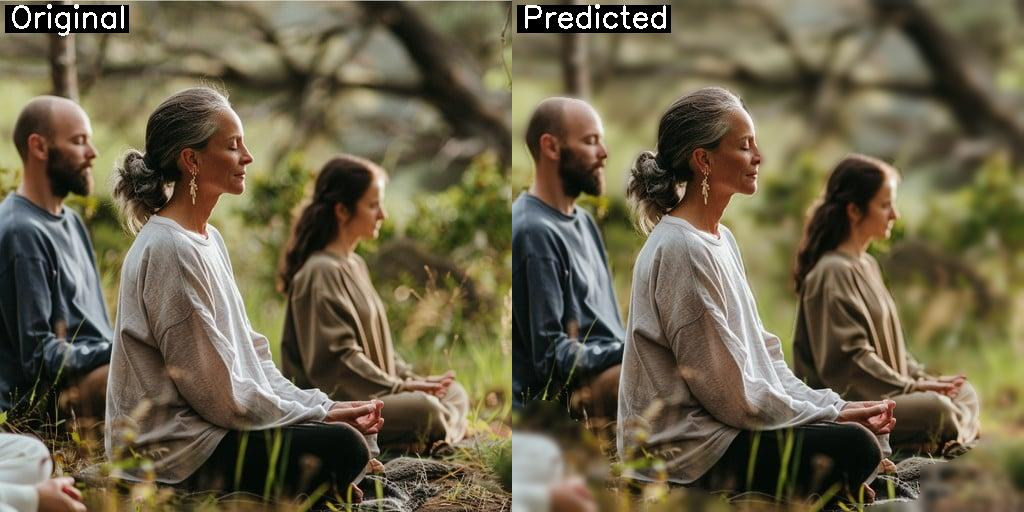

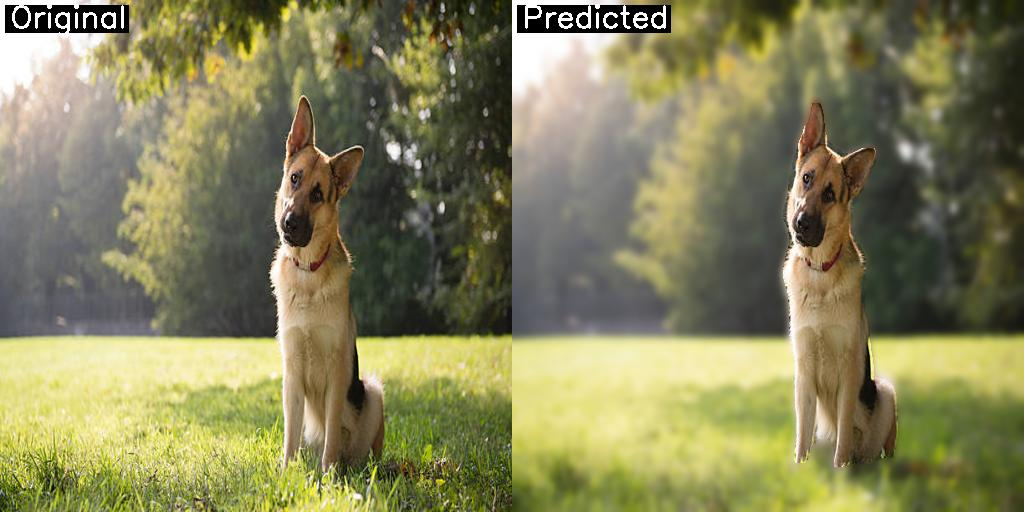

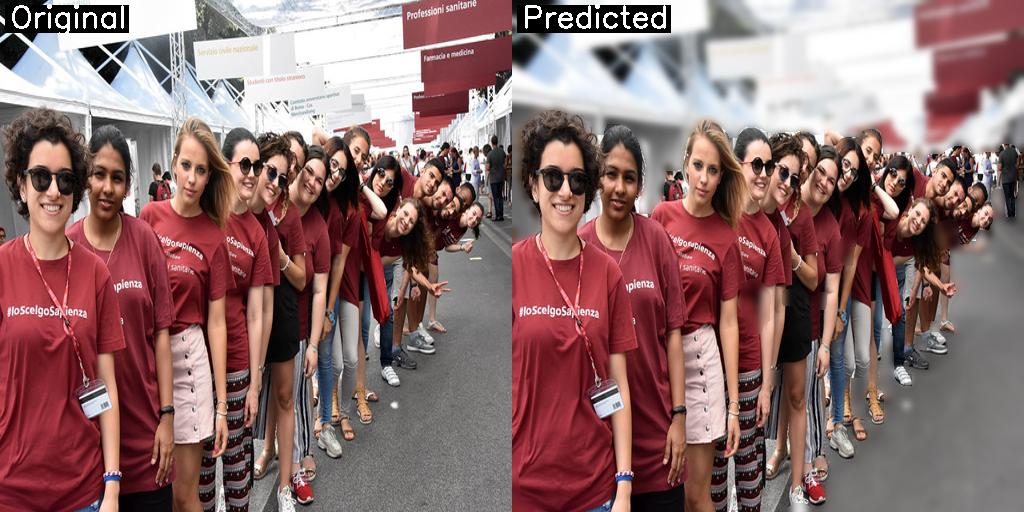

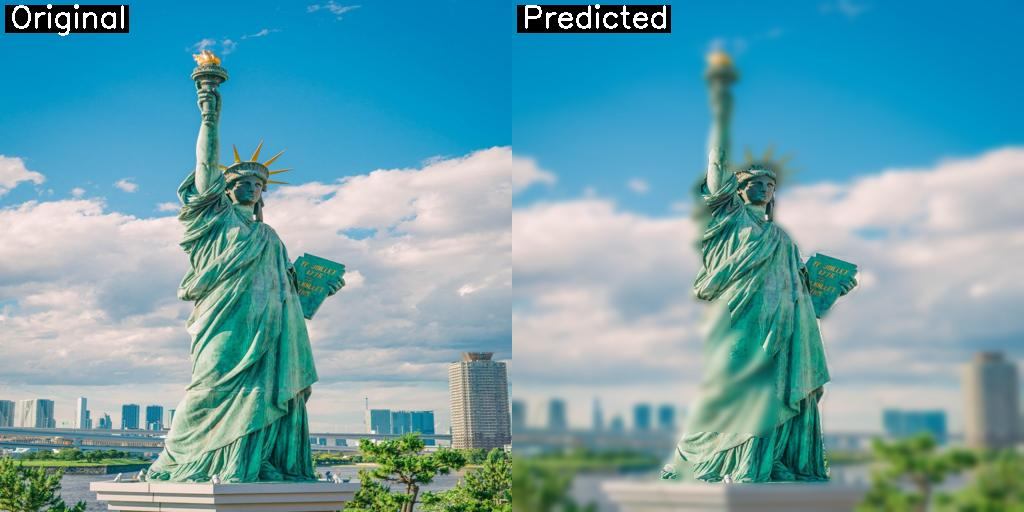

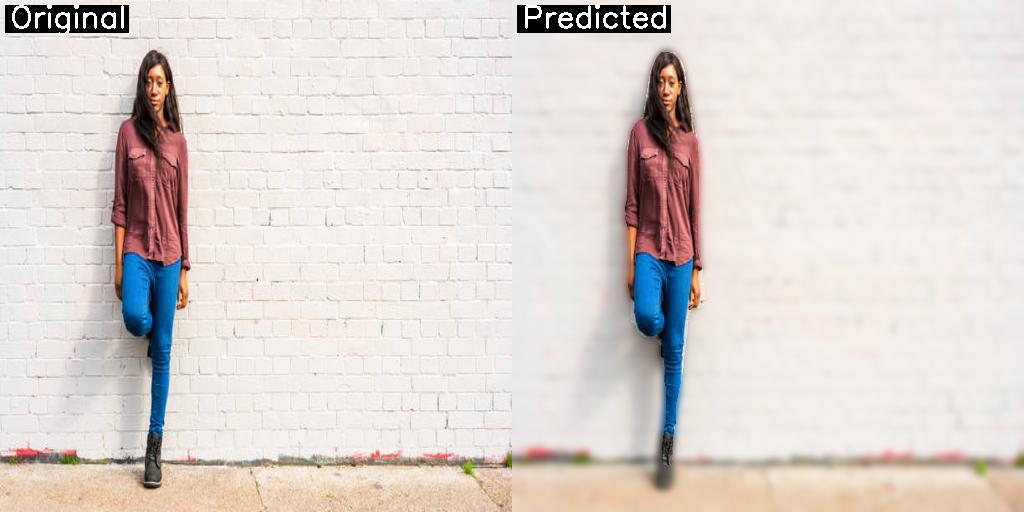

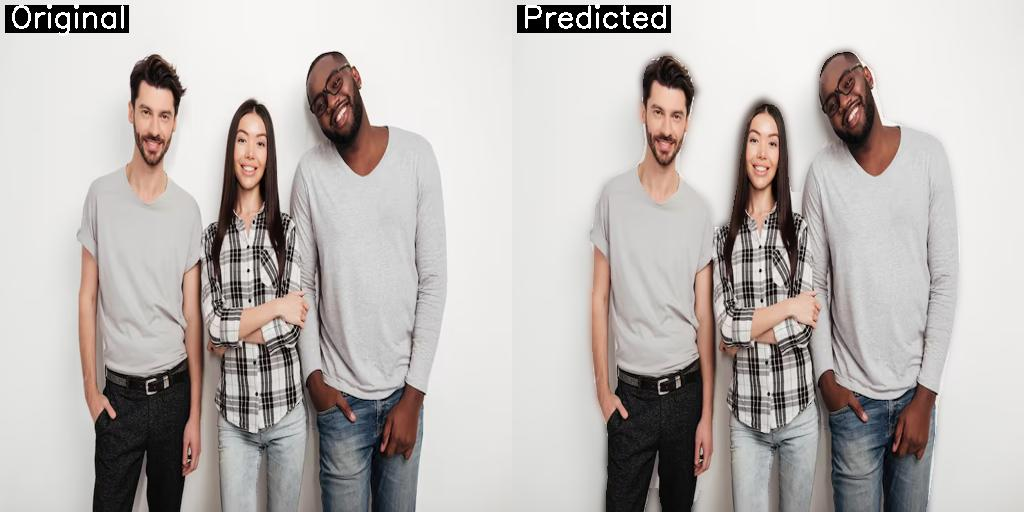

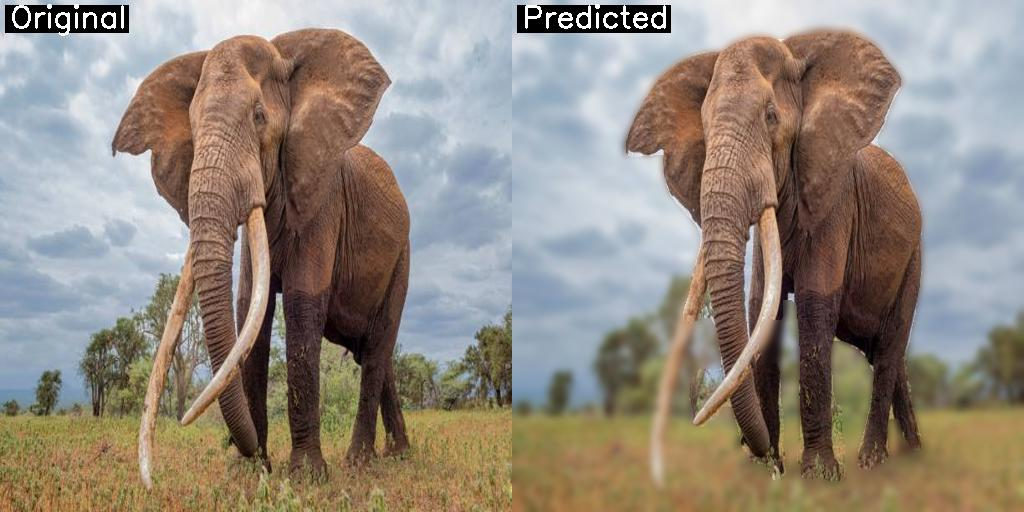

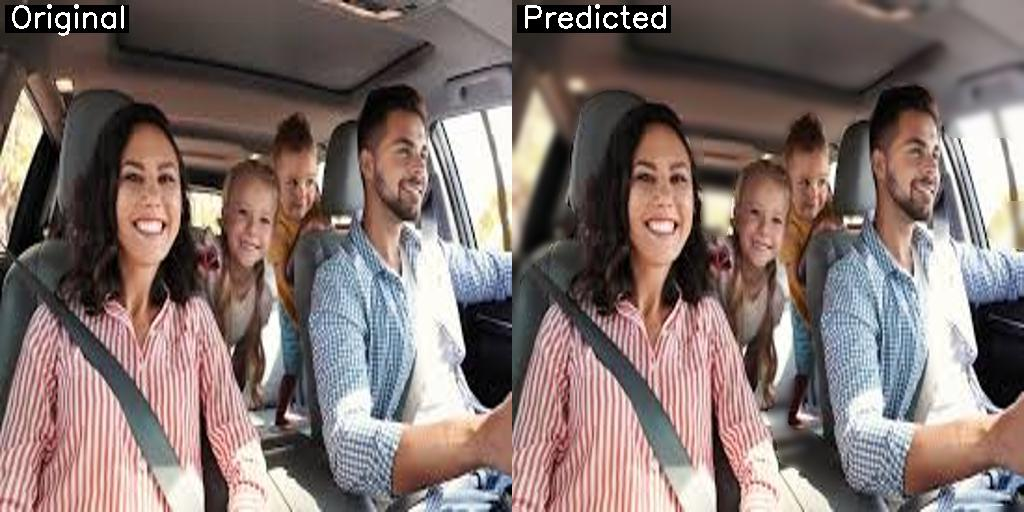

In [65]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T
from torchvision import models
import torch.nn as nn

# === 0. Setup device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Define transform ===
transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# === 2. Load your trained model ===
model = models.segmentation.deeplabv3_resnet50(weights=None, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)  # binary segmentation
state_dict = torch.load("/content/deeplabv3_custom_finetuned_head.pth", map_location=device)
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

# === 3. Predict mask ===
def predict_mask(image):
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()
    return pred

# === 4. Refinement functions ===
def refine_mask(mask):
    mask = mask.astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)

    # Remove small noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Fill gaps
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask

def keep_largest_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8))
    if num_labels <= 1:
        return mask
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # skip background
    refined = (labels == largest_label).astype(np.uint8)
    return refined

# === 5. Apply blur to background ===
def apply_blur_background(image, mask):
    image = image.resize((mask.shape[1], mask.shape[0]))
    image_np = np.array(image)

    # Blur entire image
    blurred = cv2.GaussianBlur(image_np, (21, 21), 0)

    # Copy blurred background but keep subject sharp
    result = blurred.copy()
    result[mask != 0] = image_np[mask != 0]
    return result

# === 6. Side-by-side with labels ===
def make_side_by_side_with_labels(original, predicted):
    # Resize original to match predicted height
    h = min(original.shape[0], predicted.shape[0])
    original = cv2.resize(original, (predicted.shape[1], h))
    predicted = cv2.resize(predicted, (predicted.shape[1], h))

    # Add text labels
    labeled_original = original.copy()
    labeled_predicted = predicted.copy()

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    thickness = 2
    color = (255, 255, 255)  # white text
    bg_color = (0, 0, 0)     # black background

    # Original label
    (w, h_text), _ = cv2.getTextSize("Original", font, font_scale, thickness)
    cv2.rectangle(labeled_original, (5,5), (w+10, h_text+10), bg_color, -1)
    cv2.putText(labeled_original, "Original", (10, h_text + 5), font, font_scale, color, thickness)

    # Predicted label
    (w, h_text), _ = cv2.getTextSize("Predicted", font, font_scale, thickness)
    cv2.rectangle(labeled_predicted, (5,5), (w+10, h_text+10), bg_color, -1)
    cv2.putText(labeled_predicted, "Predicted", (10, h_text + 5), font, font_scale, color, thickness)

    # Concatenate
    side_by_side = np.concatenate((labeled_original, labeled_predicted), axis=1)
    return side_by_side

# === 7. Prepare folders ===
input_dir = "/content/images_to_test/Images"   # your input folder
output_dir = "/content/results_blurred_refined"
os.makedirs(output_dir, exist_ok=True)

# === 8. Process images ===
for fname in os.listdir(input_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(input_dir, fname)
        img = Image.open(img_path).convert("RGB")

        # Predict
        pred_mask = predict_mask(img)

        # Refine mask
        pred_mask = refine_mask(pred_mask)
        pred_mask = keep_largest_component(pred_mask)

        # Apply blur
        result_img = apply_blur_background(img, pred_mask)

        # Original resized
        original_resized = np.array(img.resize((512, 512)))

        # Side-by-side with labels
        side_by_side = make_side_by_side_with_labels(original_resized, result_img)

        # Save
        out_path = os.path.join(output_dir, fname)
        Image.fromarray(side_by_side).save(out_path)
        print(f"Processed: {img_path} → {out_path}")

print("✅ Done! Refined side-by-side results saved in:", output_dir)

# === 9. Display inside notebook ===
from IPython.display import Image as IPImage, display
for fname in os.listdir(output_dir):
    display(IPImage(filename=os.path.join(output_dir, fname)))


Processed: /content/images_to_test/Images/nature.jpg → /content/results_side_by_side/nature.jpg
Processed: /content/images_to_test/Images/dog.jpg → /content/results_side_by_side/dog.jpg
Processed: /content/images_to_test/Images/students.jpg → /content/results_side_by_side/students.jpg
Processed: /content/images_to_test/Images/statue of liberty.jpg → /content/results_side_by_side/statue of liberty.jpg
Processed: /content/images_to_test/Images/wall.jpg → /content/results_side_by_side/wall.jpg
Processed: /content/images_to_test/Images/standing.jpg → /content/results_side_by_side/standing.jpg
Processed: /content/images_to_test/Images/elephant.jpg → /content/results_side_by_side/elephant.jpg
Processed: /content/images_to_test/Images/family.jpg → /content/results_side_by_side/family.jpg
✅ All images processed. Side-by-side results saved in: /content/results_side_by_side


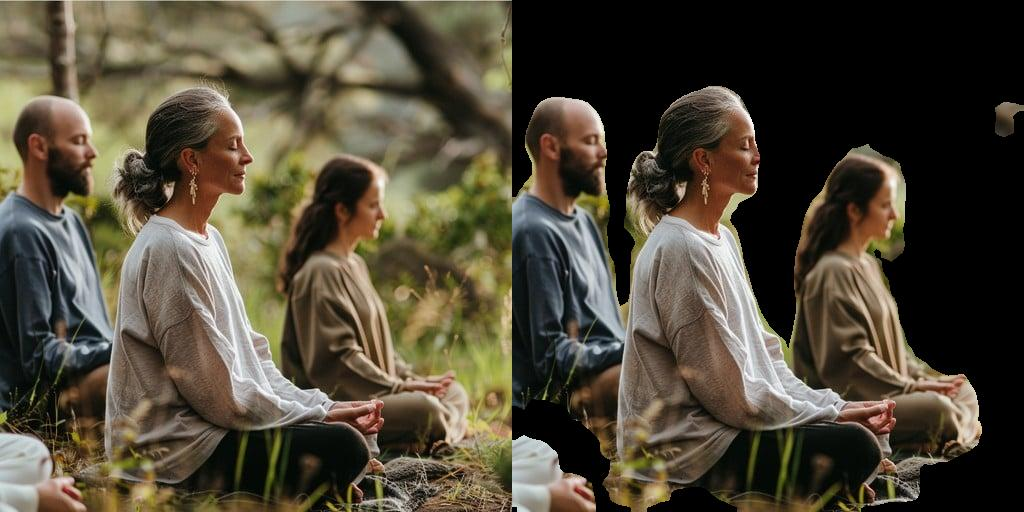

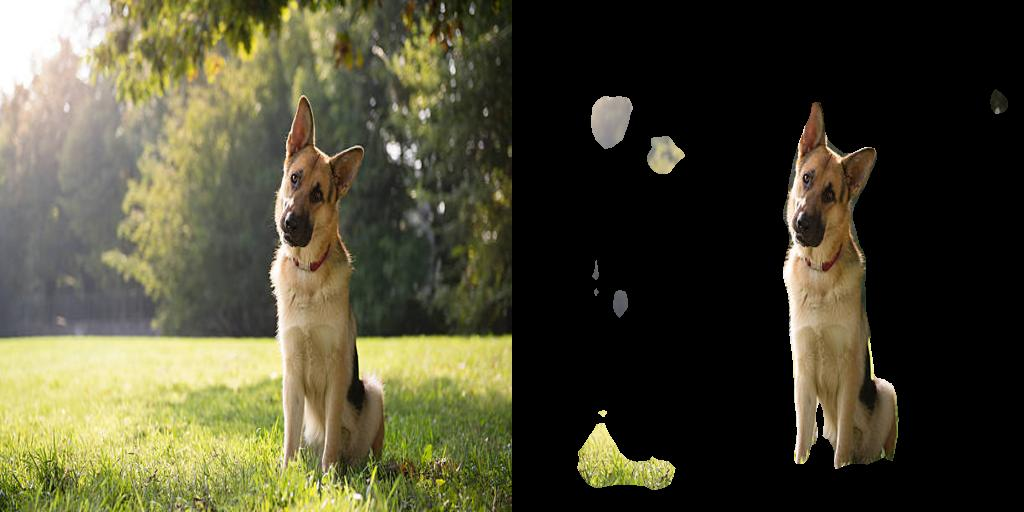

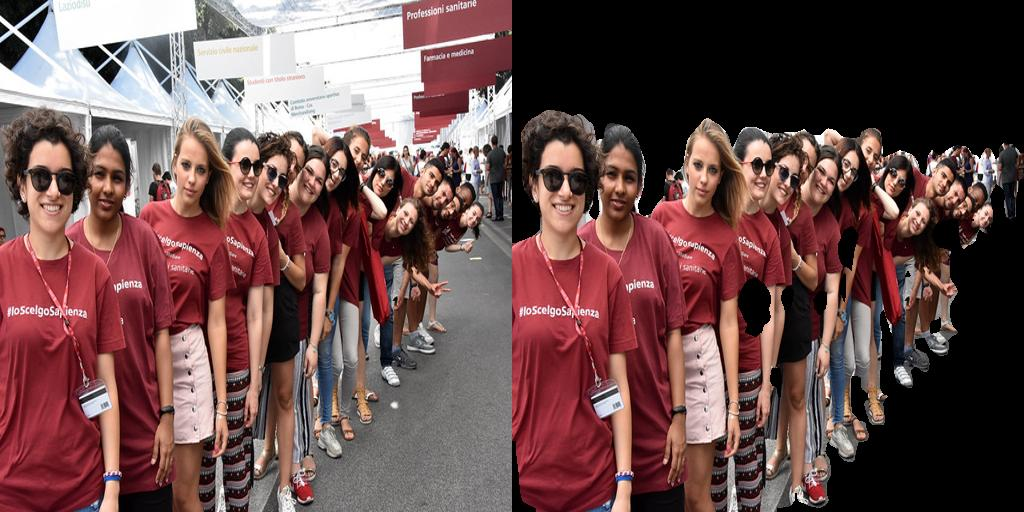

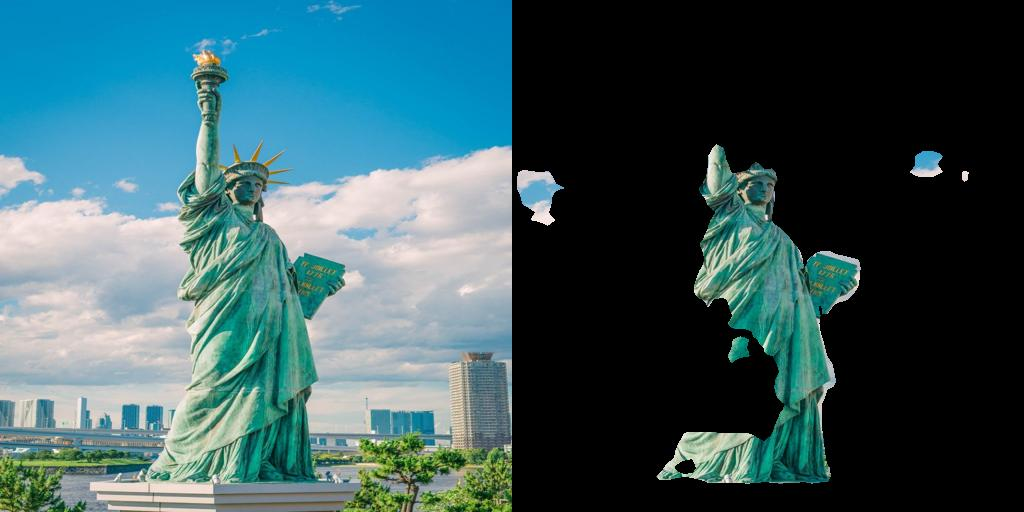

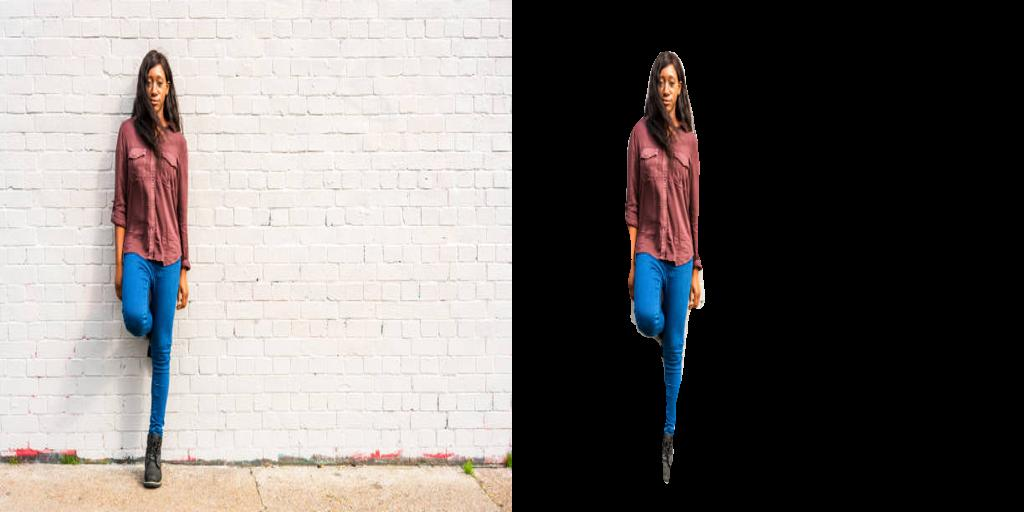

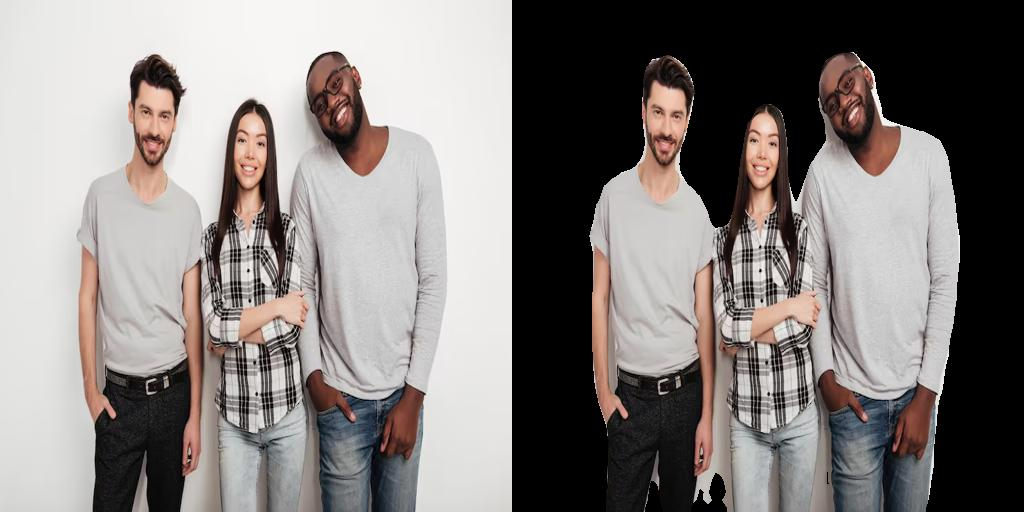

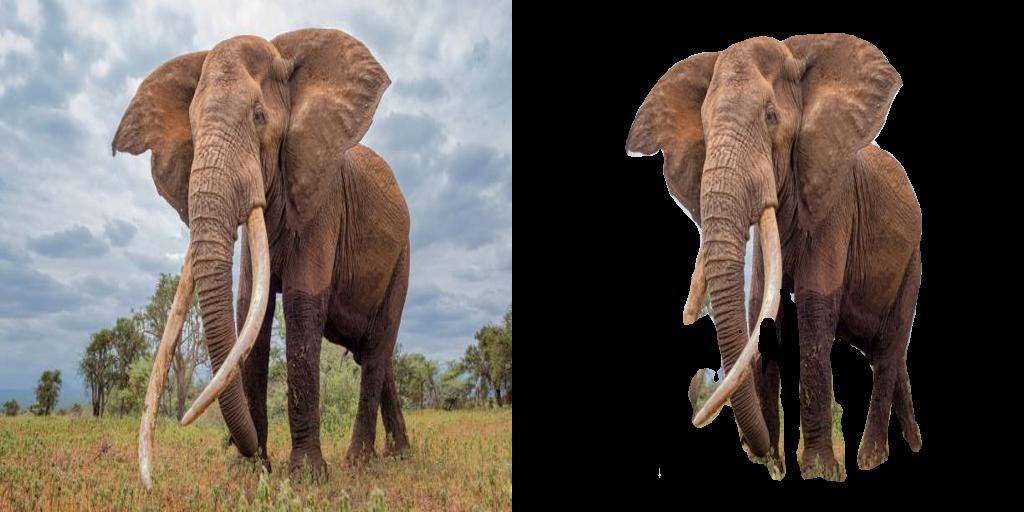

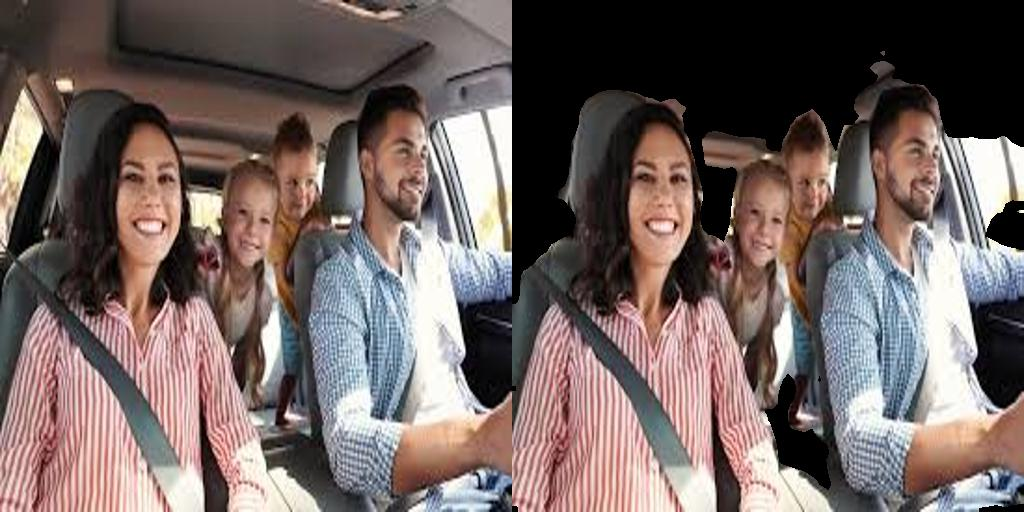

In [63]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision import models
import torch.nn as nn

# === 0. Setup device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Define transform ===
transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# === 2. Load your trained model ===
model = models.segmentation.deeplabv3_resnet50(weights=None, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)  # binary segmentation
state_dict = torch.load("/content/deeplabv3_custom_finetuned_head.pth", map_location=device)
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

# === 3. Predict mask ===
def predict_mask(image):
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()
    return pred

# === 4. Apply mask: subject only, background black ===
def apply_mask_blackbg(image, mask):
    image = image.resize((mask.shape[1], mask.shape[0]))
    image_np = np.array(image)
    result = np.zeros_like(image_np)   # all black
    result[mask != 0] = image_np[mask != 0]  # keep subject
    return result

# === 5. Create side-by-side comparison ===
def make_side_by_side(original, predicted):
    h = min(original.shape[0], predicted.shape[0])
    original = cv2.resize(original, (predicted.shape[1], h))
    predicted = cv2.resize(predicted, (predicted.shape[1], h))
    side_by_side = np.concatenate((original, predicted), axis=1)
    return side_by_side

# === 6. Prepare folders ===
input_dir = "/content/images_to_test/Images"   # your input folder
output_dir = "/content/results_side_by_side"
os.makedirs(output_dir, exist_ok=True)

# === 7. Process all images ===
for fname in os.listdir(input_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(input_dir, fname)
        img = Image.open(img_path).convert("RGB")

        # Predict mask
        pred_mask = predict_mask(img)

        # Apply black background
        result_img = apply_mask_blackbg(img, pred_mask)

        # Original resized for consistency
        original_resized = np.array(img.resize((512, 512)))

        # Side-by-side
        side_by_side = make_side_by_side(original_resized, result_img)

        # Save result
        out_path = os.path.join(output_dir, fname)
        Image.fromarray(side_by_side).save(out_path)
        print(f"Processed: {img_path} → {out_path}")

print("✅ All images processed. Side-by-side results saved in:", output_dir)

# === 8. Show inside notebook ===
from IPython.display import Image as IPImage, display
for fname in os.listdir(output_dir):
    display(IPImage(filename=os.path.join(output_dir, fname)))


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

# ================================
# Metrics Implementation
# ================================
def evaluate_model(model, dataloader, device, num_classes=2):
    model.eval()
    iou_list = []
    dice_list = []
    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            preds = torch.argmax(outputs, dim=1)

            for pred, mask in zip(preds, masks):
                pred = pred.cpu().numpy()
                mask = mask.cpu().numpy()

                for cls in range(1, num_classes):  # skip background (class 0)
                    pred_cls = (pred == cls).astype(np.uint8)
                    mask_cls = (mask == cls).astype(np.uint8)

                    intersection = np.logical_and(pred_cls, mask_cls).sum()
                    union = np.logical_or(pred_cls, mask_cls).sum()
                    dice = (2 * intersection) / (pred_cls.sum() + mask_cls.sum() + 1e-6)

                    if union > 0:  # avoid division by zero
                        iou_list.append(intersection / union)
                    dice_list.append(dice)

                # Pixel accuracy
                total_correct += (pred == mask).sum()
                total_pixels += mask.size

    mean_iou = np.mean(iou_list) if iou_list else 0
    mean_dice = np.mean(dice_list) if dice_list else 0
    pixel_acc = total_correct / total_pixels

    return mean_iou, mean_dice, pixel_acc


# ================================
# Run Evaluation
# ================================
mean_iou, mean_dice, pixel_acc = evaluate_model(model, val_loader, device, num_classes=2)

print(f"✅ Evaluation Results:")
print(f"Mean IoU:   {mean_iou:.4f}")
print(f"Mean Dice:  {mean_dice:.4f}")
print(f"Pixel Acc:  {pixel_acc:.4f}")


Evaluating: 100%|██████████| 5000/5000 [07:23<00:00, 11.28it/s]

✅ Evaluation Results:
Mean IoU:   0.5724
Mean Dice:  0.6859
Pixel Acc:  0.8711
